[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Biswajit1999/daily-astro-notebooks/blob/master/exoplanet-archive/2026-07-30-eccentricity-distribution/notebook.ipynb)

# How circular are exoplanet orbits, really?

Our own solar system's planets have nearly circular orbits (low eccentricity). I wanted to check whether that's typical, using the real measured orbital eccentricities of thousands of confirmed exoplanets, and see whether planets found by different methods show different eccentricity patterns.

In [1]:
import pyvo as vo
import numpy as np
import matplotlib.pyplot as plt

svc = vo.dal.TAPService('https://exoplanetarchive.ipac.caltech.edu/TAP')
query = '''
SELECT pl_name, pl_orbeccen, pl_orbper, discoverymethod
FROM pscomppars
WHERE pl_orbeccen IS NOT NULL
'''
tab = svc.search(query).to_table()
print(len(tab), 'confirmed planets with a measured eccentricity retrieved')

5280 confirmed planets with a measured eccentricity retrieved


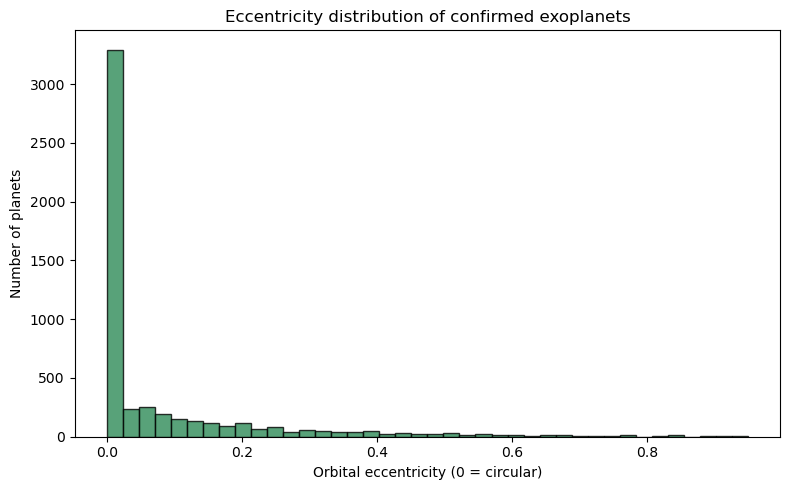

Median eccentricity: 0.0
Fraction with e > 0.4: 0.053


In [2]:
ecc = np.array(tab['pl_orbeccen'])
period = np.array(tab['pl_orbper'])

plt.figure(figsize=(8,5))
plt.hist(ecc, bins=40, color='seagreen', edgecolor='black', alpha=0.8)
plt.xlabel('Orbital eccentricity (0 = circular)')
plt.ylabel('Number of planets')
plt.title('Eccentricity distribution of confirmed exoplanets')
plt.tight_layout()
plt.savefig('eccentricity_hist.png', dpi=120)
plt.show()

print('Median eccentricity:', round(np.median(ecc), 3))
print('Fraction with e > 0.4:', round(np.mean(ecc > 0.4), 3))

In [3]:
short = period < 10   # days, close-in planets
long = period > 100
print('Median eccentricity, period < 10 days:', round(np.median(ecc[short]), 3))
print('Median eccentricity, period > 100 days:', round(np.median(ecc[long]), 3))

Median eccentricity, period < 10 days: 0.0
Median eccentricity, period > 100 days: 0.16


There's a big pileup near zero (mostly close-in planets), but a long tail out to quite eccentric orbits -- and splitting the sample by orbital period showed that short-period planets are systematically more circular than long-period ones. That's a real physical effect: strong tidal forces from the star gradually circularize a close-in planet's orbit over time, while planets further out don't feel that effect as strongly and can retain more eccentric orbits from however they formed.

**What I'd look at next:** Look specifically at multi-planet systems, where eccentricities also get damped by mutual gravitational interactions, to separate tidal circularization from that second effect.

**Citation:** This research has made use of the NASA Exoplanet Archive, which is operated by the California Institute of Technology, under contract with NASA under the Exoplanet Exploration Program. See https://exoplanetarchive.ipac.caltech.edu/docs/acknowledge.html.